In [6]:
import matplotlib.pyplot as plt
import numpy as np

import fastf1


session = fastf1.get_session(2020, 'Monza', 'Q')
session.load()

lap = session.laps.pick_fastest()
pos = lap.get_pos_data()

circuit_info = session.get_circuit_info()

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\aless\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api          

In [7]:
def rotate(xy, *, angle):
    rot_mat = np.array([[np.cos(angle), np.sin(angle)],
                        [-np.sin(angle), np.cos(angle)]])
    return np.matmul(xy, rot_mat)

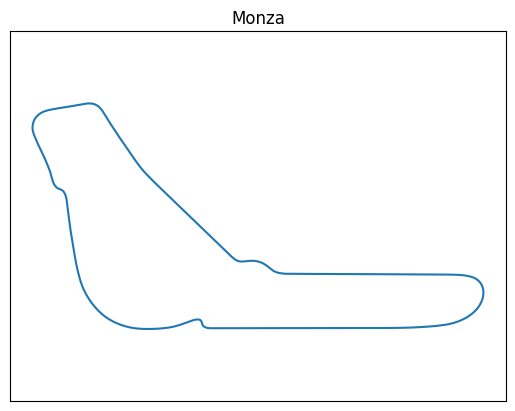

In [8]:
# Get an array of shape [n, 2] where n is the number of points and the second
# axis is x and y.
track = pos.loc[:, ('X', 'Y')].to_numpy()

# Convert the rotation angle from degrees to radian.
track_angle = circuit_info.rotation / 180 * np.pi

# Rotate and plot the track map.
rotated_track = rotate(track, angle=track_angle)
rotated_track = np.vstack([rotated_track, rotated_track[0]])  # close the loop

plt.plot(rotated_track[:, 0], rotated_track[:, 1])

plt.title(session.event['Location'])
plt.xticks([])
plt.yticks([])
plt.axis('equal')
plt.show()

Total track length: 57653


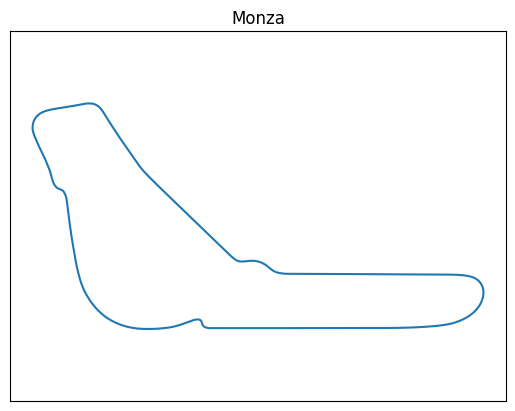

In [9]:
from scipy.interpolate import splprep, splev

track = rotated_track

tck, u = splprep([track[:, 0], track[:, 1]], s=0, per=True)

u_fine = np.linspace(0, 1, 10000)
x_fine, y_fine = splev(u_fine, tck)
pts_fine = np.column_stack([x_fine, y_fine])
total_length = np.sum(np.linalg.norm(np.diff(pts_fine, axis=0), axis=1))
print(f"Total track length: {total_length:.0f}")

# Resample every ~5(m?)
n_points = int(total_length / 50)
u_uniform = np.linspace(0, 1, n_points)
x_res, y_res = splev(u_uniform, tck)
centerline = np.column_stack([x_res, y_res])

plt.plot(centerline[:, 0], centerline[:, 1])

plt.title(session.event['Location'])
plt.xticks([])
plt.yticks([])
plt.axis('equal')
plt.show()